In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# Direktori dataset
train_dir = "intel-image-classification/seg_train/seg_train"
val_dir = "intel-image-classification/seg_test/seg_test"
# Augmentasi data
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2,
horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(150, 150),
batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(150, 150), batch_size=32,
class_mode='categorical')
# Definisi model CNN
model = Sequential([
 Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
 MaxPooling2D(2,2),
 Conv2D(64, (3,3), activation='relu'),
 MaxPooling2D(2,2),
 Flatten(),
 Dense(128, activation='relu'),
 Dropout(0.5),
 Dense(6, activation='softmax')
])
 # Kompilasi model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Training model
model.fit(train_generator, validation_data=val_generator, epochs=10)
 # Simpan model
model.save('cnn_model.h5')


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


c:\Users\Arya\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Arya\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
  5/439 ━━━━━━━━━━━━━━━━━━━━ 38:16 5s/step - accuracy: 0.1664 - loss: 7.4220

KeyboardInterrupt: 

In [4]:
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import time

# Load model yang telah dilatih
model = load_model('cnn_model.h5')

# Load label kelas
class_labels = list(train_generator.class_indices.keys())
cap = cv2.VideoCapture(0)

# List untuk menyimpan data intensitas cahaya
time_stamps = []
light_intensities = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Mode Night Vision dengan konversi ke skala abu-abu
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    night_vision = cv2.applyColorMap(gray, cv2.COLORMAP_JET)
    
    # Hitung intensitas cahaya sebagai rata-rata pixel pada gambar abu-abu
    light_intensity = np.mean(gray)
    
    # Simpan data waktu dan intensitas
    time_stamps.append(time.strftime("%H:%M:%S"))
    light_intensities.append(light_intensity)
    
    # Preprocessing gambar untuk prediksi
    img = cv2.resize(frame, (150, 150))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    
    # Prediksi kelas
    pred = model.predict(img)
    label = class_labels[np.argmax(pred)]
    
    # Tampilkan hasil pada frame
    cv2.putText(frame, f'Class: {label}', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f'Light: {light_intensity:.2f}', (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    
    # Tampilkan hasil di jendela
    cv2.imshow('Frame', frame)
    cv2.imshow('Night Vision', night_vision)
    
    print(f"Time: {time_stamps[-1]}, Light Intensity: {light_intensity:.2f}")
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# Simpan data intensitas cahaya ke file Excel
df = pd.DataFrame({"Time": time_stamps, "Light Intensity": light_intensities})
df.to_excel("light_intensity_data.xlsx", index=False)

print("Data intensitas cahaya telah disimpan ke 'light_intensity_data.xlsx'")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
Time: 17:11:37, Light Intensity: 144.43
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Time: 17:11:38, Light Intensity: 133.61
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Time: 17:11:40, Light Intensity: 132.30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
Time: 17:11:44, Light Intensity: 130.96
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
Time: 17:11:45, Light Intensity: 130.41
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Time: 17:11:45, Light Intensity: 130.42
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 945ms/step
Time: 17:11:46, Light Intensity: 130.36
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Time: 17:11:48, Light Intensity: 130.89
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Time: 17:11:48, Light Intensity: 135.14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
Time: 17:11:49, Light Intensity: 141.97
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Time: 17:11:49, Light Intensity: 144.35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
Time: 17:11:50, Light Intensity: 147.31
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Time: 17:11:50, Lig

ModuleNotFoundError: No module named 'openpyxl'

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

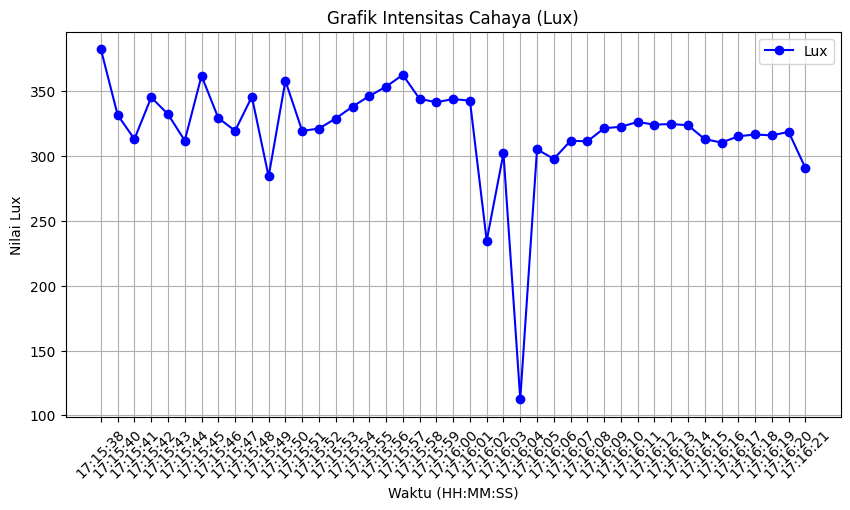

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import datetime
from tensorflow.keras.models import load_model

# Load model yang telah dilatih
model = load_model('cnn_model.h5')

# Load label kelas
class_labels = list(train_generator.class_indices.keys())

# Inisialisasi kamera
cap = cv2.VideoCapture(0)

# Faktor kalibrasi lux agar lebih akurat
LUX_CALIBRATION_FACTOR = 2.5

# Data untuk grafik
lux_values = []
timestamps = []
seen_timestamps = set()  # Set untuk menyimpan waktu unik

# Fungsi untuk menentukan kategori pencahayaan
def categorize_lux(lux):
    if lux < 60:
        return "Gelap"
    elif lux < 150:
        return "Redup"
    elif lux < 250:
        return "Sedang"
    elif lux < 350:
        return "Cukup Terang"
    else:
        return "Terang"

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Mode Night Vision
    night_vision = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    night_vision = cv2.applyColorMap(night_vision, cv2.COLORMAP_JET)

    # Preprocessing gambar untuk prediksi
    img = cv2.resize(frame, (150, 150))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Prediksi kelas objek
    pred = model.predict(img)
    label = class_labels[np.argmax(pred)]

    # --- Perhitungan Lux ---
    R, G, B = frame[:, :, 2], frame[:, :, 1], frame[:, :, 0]
    luminance = (0.2126 * R + 0.7152 * G + 0.0722 * B).mean()
    lux_value = luminance * LUX_CALIBRATION_FACTOR
    category = categorize_lux(lux_value)

    # Ambil waktu saat ini (hanya detik)
    current_time = datetime.datetime.now().strftime('%H:%M:%S')

    # Simpan data ke grafik hanya jika waktu unik
    if current_time not in seen_timestamps:
        timestamps.append(current_time)
        lux_values.append(lux_value)
        seen_timestamps.add(current_time)

    # Tampilkan informasi pada frame
    cv2.putText(frame, f'Class: {label}', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f'Lux: {lux_value:.2f} ({category})', (50, 90), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
    cv2.putText(frame, f'Time: {current_time}', (50, 130), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Tampilkan frame utama dan night vision
    cv2.imshow('Frame', frame)
    cv2.imshow('Night Vision', night_vision)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Tutup kamera
cap.release()
cv2.destroyAllWindows()

# --- Grafik Luxmeter ---
plt.figure(figsize=(10, 5))
plt.plot(timestamps, lux_values, marker='o', linestyle='-', color='b', label="Lux")
plt.xlabel("Waktu (HH:MM:SS)")
plt.ylabel("Nilai Lux")
plt.title("Grafik Intensitas Cahaya (Lux)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()